<a href="https://colab.research.google.com/github/maciekpopik/ENEN-645-Group-4-Final/blob/main/PlantLab2RealGeneralization_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Dataset Paths

DATASET_ROOT = "/content/drive/MyDrive/PlantLab2RealGeneralization"

TRAIN_DIR = f"{DATASET_ROOT}/Train"
VAL_DIR   = f"{DATASET_ROOT}/Val"
TEST_DIR  = f"{DATASET_ROOT}/Test_ID"

In [ ]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np

AUTOTUNE = tf.data.AUTOTUNE

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
#Load Datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

Found 27694 files belonging to 30 classes.
Found 5940 files belonging to 30 classes.
Found 5929 files belonging to 30 classes.


In [ ]:
#Normalization

normalize = tf.keras.layers.Rescaling(1.0/255)

In [ ]:
#Data augmentation (Real-world Domain Shift)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.4),
    tf.keras.layers.RandomTranslation(0.2, 0.2),
    tf.keras.layers.RandomContrast(0.35),
])


In [ ]:
#Preprocessing functons including random brightness and color shift

def preprocess_train(image, label):
    image = data_augmentation(image, training=True)
    image = tf.image.random_brightness(image, 0.3)
    image = tf.image.random_saturation(image, 0.6, 1.4)
    image = tf.image.random_hue(image, 0.08)
    image = normalize(image)
    return image, label

def preprocess_eval(image, label):
    image = normalize(image)
    return image, label



In [ ]:
#Apply Pipelines
train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

test_ds = test_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


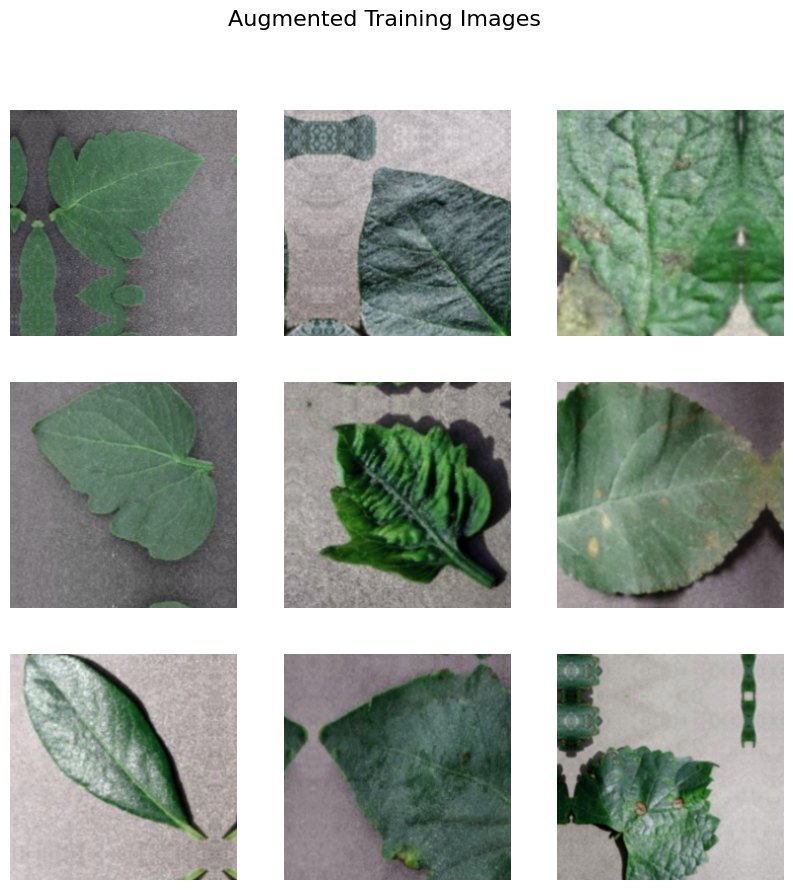

In [ ]:
# Take ONE augmented batch
for images, labels in train_ds.take(1):

    plt.figure(figsize=(10, 10))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.axis("off")

    plt.suptitle("Augmented Training Images", fontsize=16)
    plt.show()

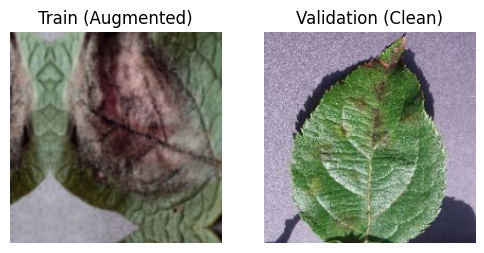

In [ ]:
# Augmented TRAIN images
for train_images, _ in train_ds.take(1):
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(train_images[0])
    plt.title("Train (Augmented)")
    plt.axis("off")

# Clean VALIDATION image
for val_images, _ in val_ds.take(1):
    plt.subplot(1,2,2)
    plt.imshow(val_images[0])
    plt.title("Validation (Clean)")
    plt.axis("off")

plt.show()

In [ ]:
#Sanity check (pixel values)
for images, _ in train_ds.take(1):
    print("Min pixel value:", tf.reduce_min(images).numpy())
    print("Max pixel value:", tf.reduce_max(images).numpy())


Min pixel value: -0.00011113509
Max pixel value: 0.999889
